In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import time
import multiprocessing

from collections import Counter
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.metrics import confusion_matrix, r2_score, mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report, precision_recall_curve
import warnings
warnings.filterwarnings("ignore")

In [2]:
#  Load dataset
df = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Train.txt", sep=",", names=[
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    "attack", "lastflag"
])
df.head()

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [3]:
df.shape

(125973, 43)

In [4]:
df.describe()

,duration,srcbytes,dstbytes,land,wrongfragment,urgent,hot,numfailedlogins,loggedin,numcompromised,...,dsthostsrvcount,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,lastflag
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [5]:
# Check unique values in the attack column
print("Unique values in 'attack' column:", df['attack'].unique())
print("Value counts in 'attack' column:\n", df['attack'].value_counts())

Unique values in 'attack' column: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']
Value counts in 'attack' column:
 attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [6]:
# Temporary diagnostic cell
print("DataFrame shape before preprocessing:", df.shape)
print("Unique attack values before preprocessing:", df['attack'].unique())

DataFrame shape before preprocessing: (125973, 43)
Unique attack values before preprocessing: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Load training data
df_train = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Train.txt", sep=",", names=[
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    "attack", "lastflag"
])

# Define encoders
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

# Encode categorical features
df_train['protocoltype'] = le_protocol.fit_transform(df_train['protocoltype'])
df_train['service'] = le_service.fit_transform(df_train['service'])
df_train['flag'] = le_flag.fit_transform(df_train['flag'])

# Binarize target
df_train['attack'] = df_train['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)

# Define features and target (41 features for SVM)
X = df_train.drop(['attack', 'lastflag'], axis=1)
y = df_train['attack']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_svm, y_train_svm = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_train_svm = scaler.fit_transform(X_train_svm)
X_test_svm = scaler.transform(X_test)
y_test_svm = y_test

# Verify shapes
print("Shape of X_train_svm:", X_train_svm.shape)
print("Shape of y_train_svm:", y_train_svm.shape)
print("Shape of X_test_svm:", X_test_svm.shape)
print("Shape of y_test_svm:", y_test_svm.shape)
print("Unique values in y_train_svm:", np.unique(y_train_svm))

Shape of X_train_svm: (107748, 41)
Shape of y_train_svm: (107748,)
Shape of X_test_svm: (25195, 41)
Shape of y_test_svm: (25195,)
Unique values in y_train_svm: [0 1]


In [8]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# Verify training data
print("Shape of X_train_svm:", X_train_svm.shape)
print("Shape of y_train_svm:", y_train_svm.shape)
print("Unique values in y_train_svm:", np.unique(y_train_svm))

# Train SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

# Predict on training set
train_pred = svm_model.predict(X_train_svm)
print("SVM Training Accuracy:", accuracy_score(y_train_svm, train_pred))
print("SVM Training Classification Report:\n", classification_report(y_train_svm, train_pred, target_names=['Normal', 'Attack']))

# Cross-validation
cv_scores = cross_val_score(svm_model, X_train_svm, y_train_svm, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean(), "±", cv_scores.std())

# Predict on test set
test_pred = svm_model.predict(X_test_svm)
print("SVM Test Accuracy:", accuracy_score(y_test_svm, test_pred))
print("SVM Test Classification Report:\n", classification_report(y_test_svm, test_pred, target_names=['Normal', 'Attack']))

Shape of X_train_svm: (107748, 41)
Shape of y_train_svm: (107748,)
Unique values in y_train_svm: [0 1]
SVM Training Accuracy: 0.9924824590711661
SVM Training Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     53874
      Attack       0.99      0.99      0.99     53874

    accuracy                           0.99    107748
   macro avg       0.99      0.99      0.99    107748
weighted avg       0.99      0.99      0.99    107748

Cross-Validation Accuracy Scores: [0.99229698 0.99174014 0.99071926 0.99146132 0.99150773]
Mean CV Accuracy: 0.9915450855596036 ± 0.0005086847725710228
SVM Test Accuracy: 0.9923794403651518
SVM Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13469
      Attack       0.99      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import numpy as np

# Verify training data
print("Shape of X_train_svm for svm_model_prob:", X_train_svm.shape)

# Train SVM model with probability
svm_model_prob = SVC(kernel='rbf', probability=True, random_state=42)
svm_model_prob.fit(X_train_svm, y_train_svm)

# Verify model
print("Number of features in svm_model_prob:", svm_model_prob.n_features_in_)
train_pred_prob = svm_model_prob.predict(X_train_svm)
print("SVM (prob) Training Accuracy:", accuracy_score(y_train_svm, train_pred_prob))

Shape of X_train_svm for svm_model_prob: (107748, 41)
Number of features in svm_model_prob: 41
SVM (prob) Training Accuracy: 0.9924824590711661


In [78]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np
import joblib

# Load training data
df_train = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Train.txt", sep=",", names=[
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    "attack", "lastflag"
])

# Diagnostic: Initial checks
print("Initial DataFrame shape:", df_train.shape)
print("Initial unique values in 'attack' column:", df_train['attack'].unique())

# Encode categorical features
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()
df_train['protocoltype'] = le_protocol.fit_transform(df_train['protocoltype'])
df_train['service'] = le_service.fit_transform(df_train['service'])
df_train['flag'] = le_flag.fit_transform(df_train['flag'])

# Binarize target
df_train['attack'] = df_train['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)
y = df_train['attack']
print("Unique values in y after binarization:", y.unique())
print("Value counts in y after binarization:\n", y.value_counts())

# Define features (38 features for LSTM)
lstm_features = [col for col in df_train.columns if col not in ['attack', 'lastflag', 'numoutboundcmds', 'isguestlogin', 'ishostlogin']]
print("LSTM training features (should be 38):", len(lstm_features))
print("LSTM feature names:", lstm_features)
X = df_train[lstm_features]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Scale features
scaler_lstm = StandardScaler()
X_train_lstm = scaler_lstm.fit_transform(X_train_smote)
X_test_lstm = scaler_lstm.transform(X_test)

# Reshape for LSTM
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], 1, X_train_lstm.shape[1]))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], 1, X_test_lstm.shape[1]))
print("Training set shape (LSTM):", X_train_lstm.shape, y_train_smote.shape)
print("Testing set shape (LSTM):", X_test_lstm.shape, y_test.shape)

# Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(1, 38), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Train model
history = model.fit(X_train_lstm, y_train_smote, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_lstm, y_test)
print(f'LSTM Test accuracy: {test_acc}')

# Save model in Keras format as recommended
model.save('lstm_model.keras')

# Save scalers and encoders
joblib.dump(scaler_lstm, 'scaler_lstm.pkl')
joblib.dump(le_protocol, 'le_protocol.pkl')
joblib.dump(le_service, 'le_service.pkl')
joblib.dump(le_flag, 'le_flag.pkl')
print("Saved: ['lstm_model.keras', 'scaler_lstm.pkl', 'le_protocol.pkl', 'le_service.pkl', 'le_flag.pkl']")

Initial DataFrame shape: (125973, 43)
Initial unique values in 'attack' column: ['normal' 'neptune' 'warezclient' 'ipsweep' 'portsweep' 'teardrop' 'nmap'
 'satan' 'smurf' 'pod' 'back' 'guess_passwd' 'ftp_write' 'multihop'
 'rootkit' 'buffer_overflow' 'imap' 'warezmaster' 'phf' 'land'
 'loadmodule' 'spy' 'perl']
Unique values in y after binarization: [0 1]
Value counts in y after binarization:
 attack
0    67343
1    58630
Name: count, dtype: int64
LSTM training features (should be 38): 38
LSTM feature names: ['duration', 'protocoltype', 'service', 'flag', 'srcbytes', 'dstbytes', 'land', 'wrongfragment', 'urgent', 'hot', 'numfailedlogins', 'loggedin', 'numcompromised', 'rootshell', 'suattempted', 'numroot', 'numfilecreations', 'numshells', 'numaccessfiles', 'count', 'srvcount', 'serrorrate', 'srvserrorrate', 'rerrorrate', 'srvrerrorrate', 'samesrvrate', 'diffsrvrate', 'srvdiffhostrate', 'dsthostcount', 'dsthostsrvcount', 'dsthostsamesrvrate', 'dsthostdiffsrvrate', 'dsthostsamesrcportrat

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 64)                  │          26,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,481 (111.25 KB)

 Trainable params: 28,481 (111.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 104s 5ms/step - accuracy: 0.9616 - loss: 0.1153 - val_accuracy: 0.9879 - val_loss: 0.0347
Epoch 2/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9879 - loss: 0.0315 - val_accuracy: 0.9886 - val_loss: 0.0280
Epoch 3/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9906 - loss: 0.0262 - val_accuracy: 0.9916 - val_loss: 0.0257
Epoch 4/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.9911 - loss: 0.0254 - val_accuracy: 0.9922 - val_loss: 0.0226
Epoch 5/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9916 - loss: 0.0230 - val_accuracy: 0.9924 - val_loss: 0.0207
Epoch 6/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9925 - loss: 0.0199 - val_accuracy: 0.9942 - val_loss: 0.0203
Epoch 7/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9931 - loss: 0.0197 - val_accuracy: 0.9935 - val_loss: 0.0183
Epoch 8/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9932 - loss: 

In [11]:
#  Define LSTM model
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(1, X_train.shape[1]), return_sequences=False),  # LSTM layer
    Dropout(0.5),  # Dropout for regularization
    Dense(32, activation='relu'),  # Dense layer
    Dropout(0.5),  # Dropout for regularization
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

In [12]:
df.drop(['land','urgent','numfailedlogins','numoutboundcmds'],axis=1,inplace=True)

In [13]:
df.isna().sum()

duration                  0
protocoltype              0
service                   0
flag                      0
srcbytes                  0
dstbytes                  0
wrongfragment             0
hot                       0
loggedin                  0
numcompromised            0
rootshell                 0
suattempted               0
numroot                   0
numfilecreations          0
numshells                 0
numaccessfiles            0
ishostlogin               0
isguestlogin              0
count                     0
srvcount                  0
serrorrate                0
srvserrorrate             0
rerrorrate                0
srvrerrorrate             0
samesrvrate               0
diffsrvrate               0
srvdiffhostrate           0
dsthostcount              0
dsthostsrvcount           0
dsthostsamesrvrate        0
dsthostdiffsrvrate        0
dsthostsamesrcportrate    0
dsthostsrvdiffhostrate    0
dsthostserrorrate         0
dsthostsrvserrorrate      0
dsthostrerrorrate   

In [14]:
df.select_dtypes(exclude=[np.number])

""
0
1
2
3
4
...
125968
125969
125970
125971


In [15]:
df['attack'].loc[df['attack']!='normal']='attack'

In [16]:
le=LabelEncoder()

In [17]:
df['protocoltype']=le.fit_transform(df['protocoltype'])
df['service']=le.fit_transform(df['service'])
df['flag']=le.fit_transform(df['flag'])
df['attack']=le.fit_transform(df['attack'])

<Axes: >

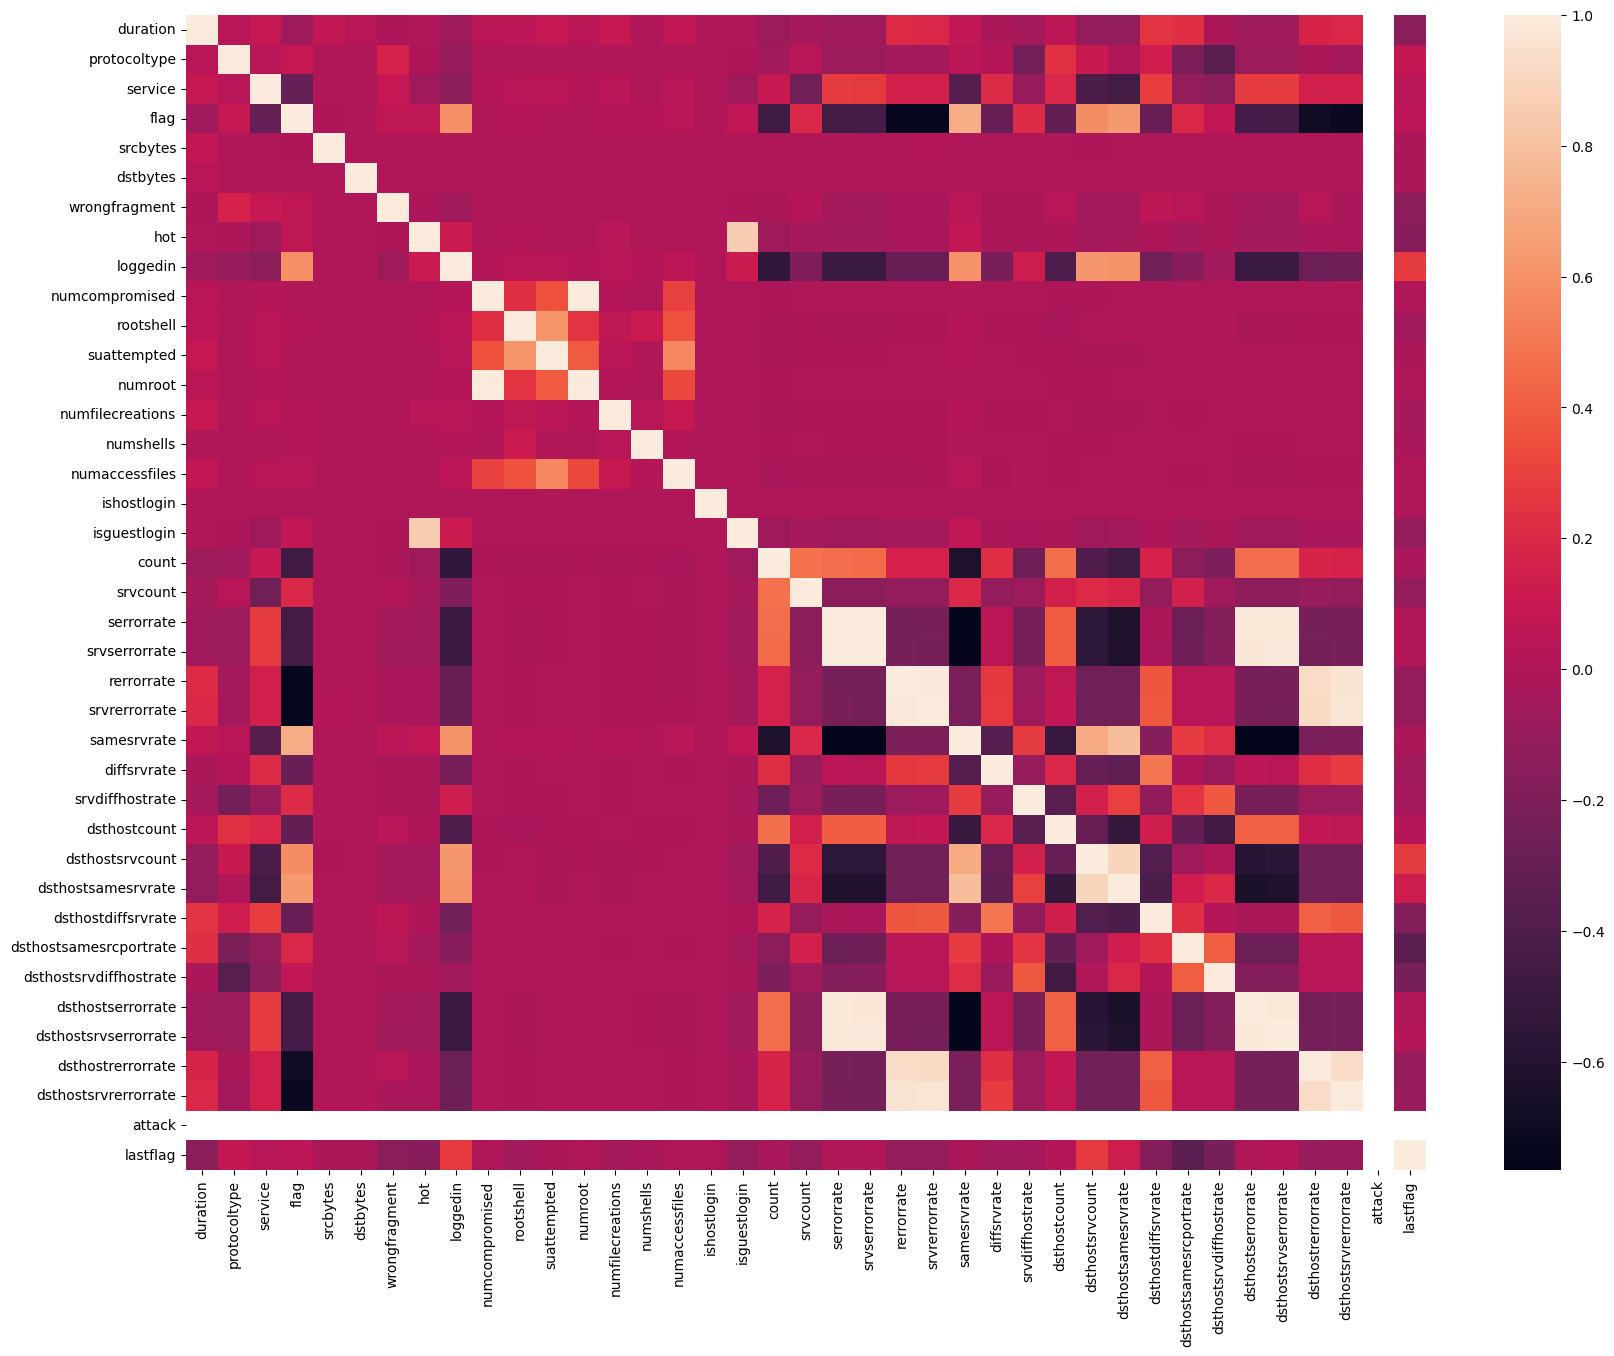

In [18]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr())

In [19]:
X=df.drop(['attack'],axis=1)
y=df['attack']

In [20]:
print("Class distribution: {}".format(Counter(y)))

Class distribution: Counter({0: 125973})


In [21]:
scaler = StandardScaler()
scaler.fit(X)
X_transformed = scaler.transform(X)

In [22]:
print("svm 2")

svm 2


In [23]:
# Cell 20: Train and evaluate SVM model with cross-validation
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
import pandas as pd
import numpy as np

# Verify training data
print("Shape of X_train_svm:", X_train_svm.shape)
print("Shape of y_train_svm:", y_train_svm.shape)
print("Unique values in y_train_svm:", np.unique(y_train_svm))

# Train SVM model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

# Predict on training set
train_pred = svm_model.predict(X_train_svm)
print("SVM Training Accuracy:", accuracy_score(y_train_svm, train_pred))
print("SVM Training Classification Report:\n", classification_report(y_train_svm, train_pred, target_names=['Normal', 'Attack']))

# Cross-validation
cv_scores = cross_val_score(svm_model, X_train_svm, y_train_svm, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean(), "±", cv_scores.std())

# Predict on test set (for consistency with Cell 49)
test_pred = svm_model.predict(X_test_svm)
print("SVM Test Accuracy:", accuracy_score(y_test_svm, test_pred))
print("SVM Test Classification Report:\n", classification_report(y_test_svm, test_pred, target_names=['Normal', 'Attack']))

Shape of X_train_svm: (107748, 41)
Shape of y_train_svm: (107748,)
Unique values in y_train_svm: [0 1]
SVM Training Accuracy: 0.9924824590711661
SVM Training Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     53874
      Attack       0.99      0.99      0.99     53874

    accuracy                           0.99    107748
   macro avg       0.99      0.99      0.99    107748
weighted avg       0.99      0.99      0.99    107748

Cross-Validation Accuracy Scores: [0.99229698 0.99174014 0.99071926 0.99146132 0.99150773]
Mean CV Accuracy: 0.9915450855596036 ± 0.0005086847725710228
SVM Test Accuracy: 0.9923794403651518
SVM Test Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13469
      Attack       0.99      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25

In [24]:
test_df = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Test.txt",sep=",",names=["duration","protocoltype","service","flag","srcbytes","dstbytes","land", "wrongfragment","urgent","hot","numfailedlogins","loggedin", "numcompromised","rootshell","suattempted","numroot","numfilecreations", "numshells","numaccessfiles","numoutboundcmds","ishostlogin",
"isguestlogin","count","srvcount","serrorrate", "srvserrorrate",
"rerrorrate","srvrerrorrate","samesrvrate", "diffsrvrate", "srvdiffhostrate","dsthostcount","dsthostsrvcount","dsthostsamesrvrate", "dsthostdiffsrvrate","dsthostsamesrcportrate",
"dsthostsrvdiffhostrate","dsthostserrorrate","dsthostsrvserrorrate",
"dsthostrerrorrate","dsthostsrvrerrorrate","attack", "lastflag"])
test_df.head()

,duration,protocoltype,service,flag,srcbytes,dstbytes,land,wrongfragment,urgent,hot,...,dsthostsamesrvrate,dsthostdiffsrvrate,dsthostsamesrcportrate,dsthostsrvdiffhostrate,dsthostserrorrate,dsthostsrvserrorrate,dsthostrerrorrate,dsthostsrvrerrorrate,attack,lastflag
0,0,tcp,private,REJ,0,0,0,0,0,0,...,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
1,0,tcp,private,REJ,0,0,0,0,0,0,...,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,neptune,21
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,normal,21
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,saint,15
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,mscan,11


In [25]:
test_df.select_dtypes(exclude=[np.number])

,protocoltype,service,flag,attack
0,tcp,private,REJ,neptune
1,tcp,private,REJ,neptune
2,tcp,ftp_data,SF,normal
3,icmp,eco_i,SF,saint
4,tcp,telnet,RSTO,mscan
...,...,...,...,...
22539,tcp,smtp,SF,normal
22540,tcp,http,SF,normal
22541,tcp,http,SF,back
22542,udp,domain_u,SF,normal


In [26]:
test_df['attack'].loc[test_df['attack']!='normal']='attack'

In [27]:
test_df['protocoltype']=le.fit_transform(test_df['protocoltype'])
test_df['service']=le.fit_transform(test_df['service'])
test_df['flag']=le.fit_transform(test_df['flag'])
test_df['attack']=le.fit_transform(test_df['attack'])

In [28]:
test_df.drop(['land','urgent','numfailedlogins','numoutboundcmds'],axis=1,inplace=True)

In [29]:
X_test=test_df.drop(['attack'],axis=1)
y_test=test_df['attack']

In [30]:
X_test_transformed = scaler.transform(X_test)

In [31]:
target_names=["attack","normal"]

In [32]:
# Cell 49: Predict and evaluate SVM on test set
from sklearn.metrics import classification_report

# Verify test data shapes and features
print("Shape of X_test_svm:", X_test_svm.shape)
print("Shape of y_test_svm:", y_test_svm.shape)
print("Unique values in y_test_svm:", np.unique(y_test_svm))

# Predict using SVM model
test_pred = svm_model.predict(X_test_svm)

# Define target names for classification report
target_names = ['Normal', 'Attack']

# Evaluate
print("SVM Classification Report:\n", classification_report(y_test_svm, test_pred, target_names=target_names))

Shape of X_test_svm: (25195, 41)
Shape of y_test_svm: (25195,)
Unique values in y_test_svm: [0 1]
SVM Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13469
      Attack       0.99      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



In [33]:
# Cell 88: Score SVM model on test set
# Use X_test_svm (41 features) instead of X_test_transformed
accuracy_score = svm_model.score(X_test_svm, y_test_svm)
print("SVM Test Accuracy:", accuracy_score)

SVM Test Accuracy: 0.9923794403651518


In [34]:
from sklearn.metrics import roc_curve, auc


In [35]:
# Cell 95: Retrain SVM with probability outputs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM with probability=True
svm_model_prob = SVC(kernel='rbf', probability=True, random_state=42)
svm_model_prob.fit(X_train_svm, y_train_svm)

# Verify accuracy (should match Cell 20)
test_pred = svm_model_prob.predict(X_test_svm)
print("SVM Test Accuracy (with probability):", accuracy_score(y_test_svm, test_pred))
print("SVM Classification Report (with probability):\n", classification_report(y_test_svm, test_pred, target_names=['Normal', 'Attack']))

SVM Test Accuracy (with probability): 0.9923794403651518
SVM Classification Report (with probability):
               precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     13469
      Attack       0.99      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



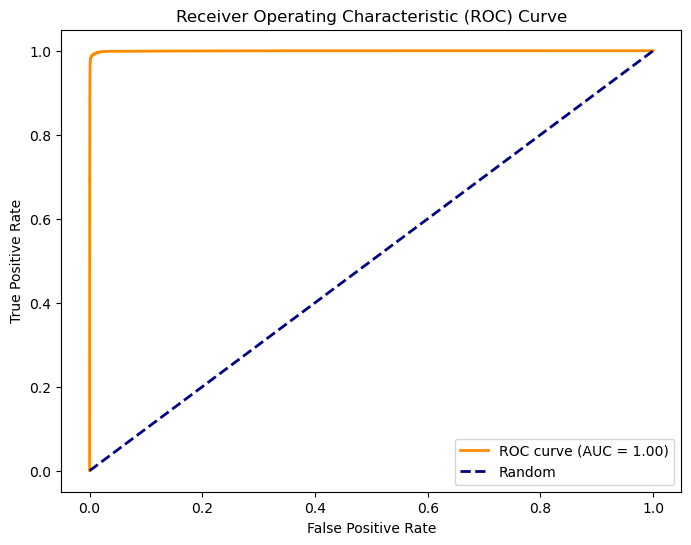

ROC AUC Score: 0.9993778139850693


In [36]:
# Cell 94: Plot ROC curve for SVM
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores
y_prob = svm_model_prob.predict_proba(X_test_svm)[:, 1]  # Probability for positive class (Attack)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_svm, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# Print AUC
print("ROC AUC Score:", roc_auc)

In [56]:
    # import pandas as pd
    # from sklearn.preprocessing import LabelEncoder, StandardScaler
    # import numpy as np
    
    # # Load training data to fit encoders and scaler
    # df_train = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Train.txt", sep=",", names=[
    #     "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    #     "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    #     "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    #     "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    #     "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    #     "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    #     "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    #     "attack", "lastflag"
    # ])
    
    # # Define encoders
    # le_protocol = LabelEncoder()
    # le_service = LabelEncoder()
    # le_flag = LabelEncoder()
    
    # # Fit encoders on training data
    # df_train['protocoltype'] = le_protocol.fit_transform(df_train['protocoltype'])
    # df_train['service'] = le_service.fit_transform(df_train['service'])
    # df_train['flag'] = le_flag.fit_transform(df_train['flag'])
    
    # # Define features and target for training
    # X_train = df_train.drop(['attack', 'lastflag'], axis=1)
    # y_train = df_train['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)
    
    # # Fit scaler on training data
    # scaler = StandardScaler()
    # X_train_scaled = scaler.fit_transform(X_train)
    
    # # Load test data
    # df_test = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Test.txt", sep=",", names=[
    #     "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    #     "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    #     "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    #     "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    #     "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    #     "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    #     "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    #     "attack", "lastflag"
    # ])
    
    # # Encode categorical features in test data
    # df_test['protocoltype'] = le_protocol.transform(df_test['protocoltype'])
    # df_test['service'] = le_service.transform(df_test['service'])
    # df_test['flag'] = le_flag.transform(df_test['flag'])
    
    # # Binarize target
    # df_test['attack'] = df_test['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)
    
    # # Define features and target
    # X_test_independent = df_test.drop(['attack', 'lastflag'], axis=1)
    # y_test_independent = df_test['attack']
    
    # # Scale features
    # X_test_independent_scaled = scaler.transform(X_test_independent)
    
    # # Reshape for LSTM
    # X_test_lstm_independent = X_test_independent_scaled.reshape((X_test_independent_scaled.shape[0], 1, X_test_independent_scaled.shape[1]))
    
    # # Verify shapes
    # print("Shape of X_test_lstm_independent:", X_test_lstm_independent.shape)
    # print("Shape of y_test_independent:", y_test_independent.shape)

In [46]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Ensure dependencies from Cell 8 are available
if 'lstm_features' not in globals() or 'scaler_lstm' not in globals() or 'le_protocol' not in globals():
    raise NameError("LSTM dependencies (lstm_features, scaler_lstm, le_protocol, le_service, le_flag) not defined. Run Cell 8 first.")

# Load test data
df_test = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Test.txt", sep=",", names=[
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    "attack", "lastflag"
])

# Encode categorical features
df_test['protocoltype'] = le_protocol.transform(df_test['protocoltype'])
df_test['service'] = le_service.transform(df_test['service'])
df_test['flag'] = le_flag.transform(df_test['flag'])

# Binarize target
df_test['attack'] = df_test['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)

# Select LSTM features (38 features)
X_test_lstm_independent = df_test[lstm_features]
y_test_independent = df_test['attack']

# Scale features
X_test_lstm_independent = scaler_lstm.transform(X_test_lstm_independent)

# Reshape for LSTM
X_test_lstm_independent = X_test_lstm_independent.reshape((X_test_lstm_independent.shape[0], 1, X_test_lstm_independent.shape[1]))

# Verify shapes
print("LSTM features (should be 38):", len(lstm_features))
print("Shape of X_test_lstm_independent (should be (22544, 1, 38)):", X_test_lstm_independent.shape)
print("Shape of y_test_independent:", y_test_independent.shape)

LSTM features (should be 38): 38
Shape of X_test_lstm_independent (should be (22544, 1, 38)): (22544, 1, 38)
Shape of y_test_independent: (22544,)


In [48]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import numpy as np

# Load training data
df_train = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Train.txt", sep=",", names=[
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    "attack", "lastflag"
])

# Encode categorical features
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()
df_train['protocoltype'] = le_protocol.fit_transform(df_train['protocoltype'])
df_train['service'] = le_service.fit_transform(df_train['service'])
df_train['flag'] = le_flag.fit_transform(df_train['flag'])

# Binarize target
df_train['attack'] = df_train['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)

# Define features (38 features for LSTM)
lstm_features = [col for col in df_train.columns if col not in ['attack', 'lastflag', 'numoutboundcmds', 'isguestlogin', 'ishostlogin']]
print("LSTM training features (should be 38):", len(lstm_features))
X = df_train[lstm_features]
y = df_train['attack']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Scale features
scaler_lstm = StandardScaler()
X_train_lstm = scaler_lstm.fit_transform(X_train_smote)
X_test_lstm = scaler_lstm.transform(X_test)

# Reshape for LSTM
X_train_lstm = X_train_lstm.reshape((X_train_lstm.shape[0], 1, X_train_lstm.shape[1]))
X_test_lstm = X_test_lstm.reshape((X_test_lstm.shape[0], 1, X_test_lstm.shape[1]))
print("Shape of X_train_lstm (1, 38):", X_train_lstm.shape)
print("Shape of X_test_lstm (1, 38):", X_test_lstm.shape)

# Define LSTM model
model = Sequential([
    LSTM(64, input_shape=(1, 38), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model.fit(X_train_lstm, y_train_smote, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_lstm, y_test)
print(f'LSTM Test accuracy: {test_acc}')

LSTM training features (should be 38): 38
Shape of X_train_lstm (1, 38): (107748, 1, 38)
Shape of X_test_lstm (1, 38): (25195, 1, 38)
Epoch 1/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9615 - loss: 0.1141 - val_accuracy: 0.9874 - val_loss: 0.0330
Epoch 2/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9866 - loss: 0.0343 - val_accuracy: 0.9891 - val_loss: 0.0284
Epoch 3/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9903 - loss: 0.0276 - val_accuracy: 0.9894 - val_loss: 0.0274
Epoch 4/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9918 - loss: 0.0230 - val_accuracy: 0.9926 - val_loss: 0.0214
Epoch 5/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9929 - loss: 0.0209 - val_accuracy: 0.9927 - val_loss: 0.0203
Epoch 6/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 21s 5ms/step - accuracy: 0.9928 - loss: 0.0195 - val_accuracy: 0.9925 - val_loss: 0.0215
Epoch 7/10
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.9927 - loss

705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


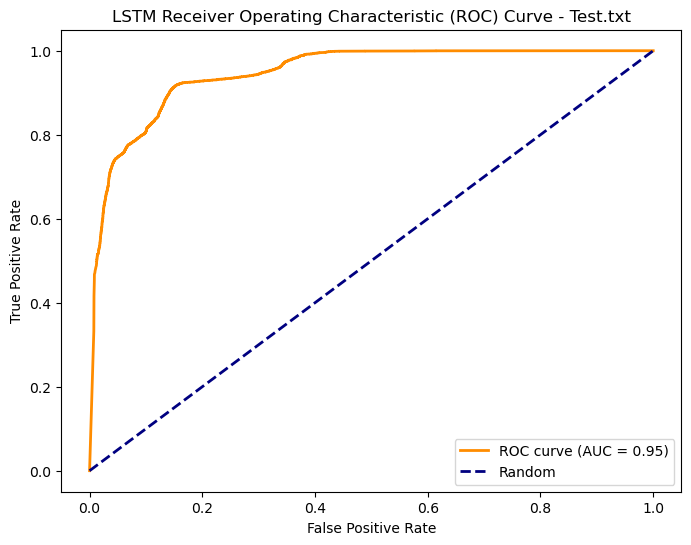

LSTM ROC AUC Score (Test.txt): 0.9465365713714521


In [50]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores
y_prob_lstm = model.predict(X_test_lstm_independent)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_independent, y_prob_lstm)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LSTM Receiver Operating Characteristic (ROC) Curve - Test.txt')
plt.legend(loc='lower right')
plt.show()

# Print AUC
print("LSTM ROC AUC Score (Test.txt):", roc_auc)

In [52]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# Load training data 
df_train = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Train.txt", sep=",", names=[
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    "attack", "lastflag"
])

# Define encoders
le_protocol = LabelEncoder()
le_service = LabelEncoder()
le_flag = LabelEncoder()

# Encode categorical features
df_train['protocoltype'] = le_protocol.fit_transform(df_train['protocoltype'])
df_train['service'] = le_service.fit_transform(df_train['service'])
df_train['flag'] = le_flag.fit_transform(df_train['flag'])

# Binarize target
df_train['attack'] = df_train['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)

# Define features and target
X = df_train.drop(['attack', 'lastflag'], axis=1)
y = df_train['attack']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Scale features
scaler = StandardScaler()
X_transformed = scaler.fit_transform(X_train_smote)
X_test_transformed = scaler.transform(X_test)

# Verify shapes
print("Shape of X_transformed:", X_transformed.shape)
print("Shape of y_train_smote:", y_train_smote.shape)
print("Shape of X_test_transformed:", X_test_transformed.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_transformed: (107748, 41)
Shape of y_train_smote: (107748,)
Shape of X_test_transformed: (25195, 41)
Shape of y_test: (25195,)


In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define DNN model
model_dnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_transformed.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compile model
model_dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train model
history = model_dnn.fit(X_transformed, y_train_smote, epochs=20, batch_size=32, validation_split=0.2)

Epoch 1/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.9502 - loss: 0.1342 - val_accuracy: 0.9866 - val_loss: 0.0383
Epoch 2/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9873 - loss: 0.0389 - val_accuracy: 0.9905 - val_loss: 0.0352
Epoch 3/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9896 - loss: 0.0319 - val_accuracy: 0.9920 - val_loss: 0.0274
Epoch 4/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9900 - loss: 0.0293 - val_accuracy: 0.9928 - val_loss: 0.0264
Epoch 5/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9910 - loss: 0.0256 - val_accuracy: 0.9919 - val_loss: 0.0350
Epoch 6/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - accuracy: 0.9916 - loss: 0.0250 - val_accuracy: 0.9936 - val_loss: 0.0237
Epoch 7/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 21s 4ms/step - accuracy: 0.9928 - loss: 0.0212 - val_accuracy: 0.9932 - val_loss: 0.0234
Epoch 8/20
2694/2694 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.9927 - loss: 0

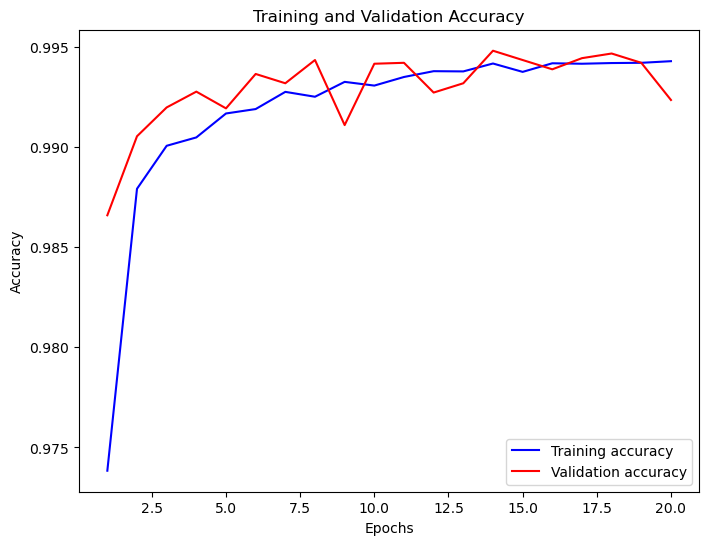

In [58]:
import matplotlib.pyplot as plt

# Extract accuracy
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']
epochs = range(1, len(training_accuracy) + 1)

# Plot training and validation accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, 'b', label='Training accuracy')
plt.plot(epochs, validation_accuracy, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [60]:
from sklearn.metrics import classification_report

# Evaluate on test set
test_loss, test_acc = model_dnn.evaluate(X_test_transformed, y_test)
print(f'Test accuracy: {test_acc}')

# Predict and generate classification report
y_pred_prob = model_dnn.predict(X_test_transformed)
y_pred = (y_pred_prob > 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred))

788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9944 - loss: 0.0154
Test accuracy: 0.9944433569908142
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     13469
           1       1.00      0.99      0.99     11726

    accuracy                           0.99     25195
   macro avg       0.99      0.99      0.99     25195
weighted avg       0.99      0.99      0.99     25195



In [62]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_transformed.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

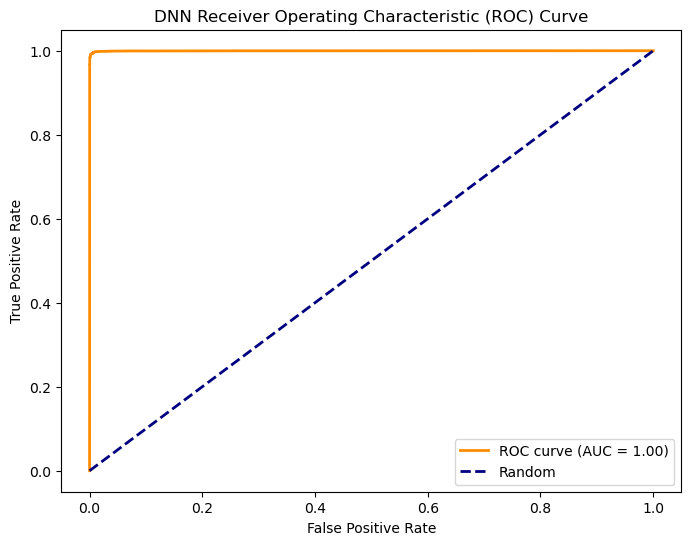

DNN ROC AUC Score: 0.9997091634238541


In [64]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('DNN Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

print("DNN ROC AUC Score:", roc_auc)

In [66]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

# Load training data to fit encoders (if not already defined)
if 'le_protocol' not in globals():
    df_train = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Train.txt", sep=",", names=[
        "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
        "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
        "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
        "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
        "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
        "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
        "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
        "attack", "lastflag"
    ])
    le_protocol = LabelEncoder()
    le_service = LabelEncoder()
    le_flag = LabelEncoder()
    df_train['protocoltype'] = le_protocol.fit_transform(df_train['protocoltype'])
    df_train['service'] = le_service.fit_transform(df_train['service'])
    df_train['flag'] = le_flag.fit_transform(df_train['flag'])
else:
    print("Using existing encoders: le_protocol, le_service, le_flag")

# Define features for LSTM (38 features)
lstm_features = [col for col in df_train.columns if col not in ['attack', 'lastflag', 'numoutboundcmds', 'isguestlogin', 'ishostlogin']]

# Fit scaler_lstm for LSTM (38 features)
scaler_lstm = StandardScaler()
scaler_lstm.fit(df_train[lstm_features])

# Load test data
df_test = pd.read_csv("C:/Users/Lenovo/Downloads/archive/Test.txt", sep=",", names=[
    "duration", "protocoltype", "service", "flag", "srcbytes", "dstbytes", "land", "wrongfragment",
    "urgent", "hot", "numfailedlogins", "loggedin", "numcompromised", "rootshell", "suattempted",
    "numroot", "numfilecreations", "numshells", "numaccessfiles", "numoutboundcmds", "ishostlogin",
    "isguestlogin", "count", "srvcount", "serrorrate", "srvserrorrate", "rerrorrate", "srvrerrorrate",
    "samesrvrate", "diffsrvrate", "srvdiffhostrate", "dsthostcount", "dsthostsrvcount",
    "dsthostsamesrvrate", "dsthostdiffsrvrate", "dsthostsamesrcportrate", "dsthostsrvdiffhostrate",
    "dsthostserrorrate", "dsthostsrvserrorrate", "dsthostrerrorrate", "dsthostsrvrerrorrate",
    "attack", "lastflag"
])

# Encode categorical features in test data
df_test['protocoltype'] = le_protocol.transform(df_test['protocoltype'])
df_test['service'] = le_service.transform(df_test['service'])
df_test['flag'] = le_flag.transform(df_test['flag'])

# Binarize target
df_test['attack'] = df_test['attack'].astype(str).str.strip().str.lower().apply(lambda x: 0 if x == 'normal' else 1)

# Define features and target
X_test_independent = df_test.drop(['attack', 'lastflag'], axis=1)
y_test_independent = df_test['attack']

# Scale features (reuse scaler from SVM preprocessing for SVM/DNN)
if 'scaler' not in globals():
    raise NameError("Scaler not defined. Run SVM preprocessing cell first.")
X_test_svm_independent = scaler.transform(X_test_independent)  # 41 features for SVM
X_test_dnn_independent = scaler.transform(X_test_independent)  # 41 features for DNN
X_test_lstm_independent = scaler_lstm.transform(df_test[lstm_features])  # 38 features for LSTM
X_test_lstm_independent = X_test_lstm_independent.reshape((X_test_lstm_independent.shape[0], 1, X_test_lstm_independent.shape[1]))

# Verify shapes
print("Shape of X_test_svm_independent:", X_test_svm_independent.shape)
print("Shape of X_test_dnn_independent:", X_test_dnn_independent.shape)
print("Shape of X_test_lstm_independent:", X_test_lstm_independent.shape)
print("Shape of y_test_independent:", y_test_independent.shape)

Using existing encoders: le_protocol, le_service, le_flag
Shape of X_test_svm_independent: (22544, 41)
Shape of X_test_dnn_independent: (22544, 41)
Shape of X_test_lstm_independent: (22544, 1, 38)
Shape of y_test_independent: (22544,)


X_test_lstm_independent shape: (22544, 1, 38)
LSTM model input shape: (None, 1, 38)
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
705/705 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


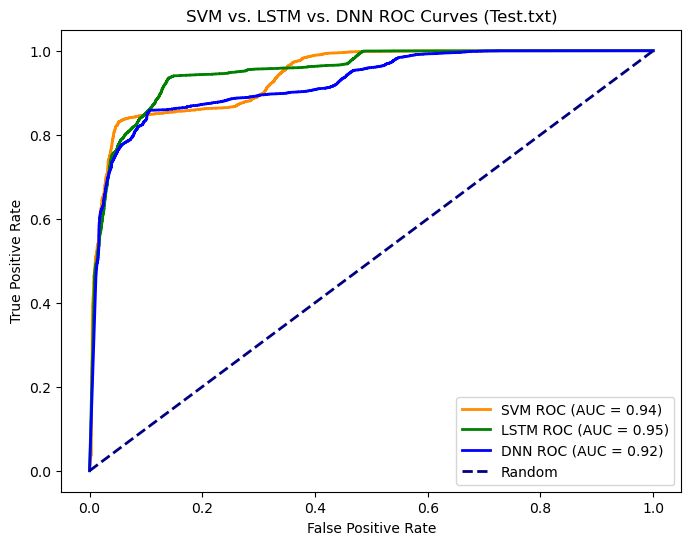

SVM ROC AUC (Test.txt): 0.94
LSTM ROC AUC (Test.txt): 0.95
DNN ROC AUC (Test.txt): 0.92


In [74]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Verify models and data
if 'svm_model_prob' not in globals():
    raise NameError("SVM model (svm_model_prob) not defined. Run SVM training cell.")
if 'model' not in globals():
    raise NameError("LSTM model (model) not defined. Run Cell 8.")
if 'model_dnn' not in globals():
    raise NameError("DNN model (model_dnn) not defined. Run DNN training cell.")
if 'X_test_lstm_independent' not in globals() or 'y_test_independent' not in globals():
    raise NameError("Test data (X_test_lstm_independent, y_test_independent) not defined. Run preprocessing cell.")

# Verify LSTM input shape
print("X_test_lstm_independent shape:", X_test_lstm_independent.shape)
print("LSTM model input shape:", model.input_shape)

# SVM ROC (on Test.txt)
y_prob_svm = svm_model_prob.predict_proba(X_test_svm_independent)[:, 1]
fpr_svm, tpr_svm, _ = roc_curve(y_test_independent, y_prob_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# LSTM ROC (on Test.txt)
y_prob_lstm = model.predict(X_test_lstm_independent)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test_independent, y_prob_lstm)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)

# DNN ROC (on Test.txt)
y_prob_dnn = model_dnn.predict(X_test_dnn_independent)
fpr_dnn, tpr_dnn, _ = roc_curve(y_test_independent, y_prob_dnn)
roc_auc_dnn = auc(fpr_dnn, tpr_dnn)

# Plot combined ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2, label=f'SVM ROC (AUC = {roc_auc_svm:.2f})')
plt.plot(fpr_lstm, tpr_lstm, color='green', lw=2, label=f'LSTM ROC (AUC = {roc_auc_lstm:.2f})')
plt.plot(fpr_dnn, tpr_dnn, color='blue', lw=2, label=f'DNN ROC (AUC = {roc_auc_dnn:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('SVM vs. LSTM vs. DNN ROC Curves (Test.txt)')
plt.legend(loc='lower right')
plt.show()

# Print AUC scores
print(f"SVM ROC AUC (Test.txt): {roc_auc_svm:.2f}")
print(f"LSTM ROC AUC (Test.txt): {roc_auc_lstm:.2f}")
print(f"DNN ROC AUC (Test.txt): {roc_auc_dnn:.2f}")

In [80]:
from sklearn.metrics import accuracy_score, precision_score, f1_score

# Verify that predictions and test labels exist from Cell 70
if 'y_prob_svm' not in globals() or 'y_prob_lstm' not in globals() or 'y_prob_dnn' not in globals() or 'y_test_independent' not in globals():
    raise NameError("Predictions (y_prob_svm, y_prob_lstm, y_prob_dnn) or y_test_independent not defined. Run Cell 70 first.")

# Binarize predictions (threshold 0.5)
y_pred_svm = (y_prob_svm > 0.5).astype(int)
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)
y_pred_dnn = (y_prob_dnn > 0.5).astype(int)

# Compute metrics
svm_accuracy = accuracy_score(y_test_independent, y_pred_svm)
svm_precision = precision_score(y_test_independent, y_pred_svm)
svm_f1 = f1_score(y_test_independent, y_pred_svm)

lstm_accuracy = accuracy_score(y_test_independent, y_pred_lstm)
lstm_precision = precision_score(y_test_independent, y_pred_lstm)
lstm_f1 = f1_score(y_test_independent, y_pred_lstm)

dnn_accuracy = accuracy_score(y_test_independent, y_pred_dnn)
dnn_precision = precision_score(y_test_independent, y_pred_dnn)
dnn_f1 = f1_score(y_test_independent, y_pred_dnn)

# Print metrics
print("SVM Metrics (Test.txt):")
print(f"Accuracy: {svm_accuracy:.2f}, Precision: {svm_precision:.2f}, F1-Score: {svm_f1:.2f}")
print("LSTM Metrics (Test.txt):")
print(f"Accuracy: {lstm_accuracy:.2f}, Precision: {lstm_precision:.2f}, F1-Score: {lstm_f1:.2f}")
print("DNN Metrics (Test.txt):")
print(f"Accuracy: {dnn_accuracy:.2f}, Precision: {dnn_precision:.2f}, F1-Score: {dnn_f1:.2f}")

SVM Metrics (Test.txt):
Accuracy: 0.78, Precision: 0.97, F1-Score: 0.77
LSTM Metrics (Test.txt):
Accuracy: 0.78, Precision: 0.97, F1-Score: 0.76
DNN Metrics (Test.txt):
Accuracy: 0.78, Precision: 0.97, F1-Score: 0.76
